### Problem 1: Line plots

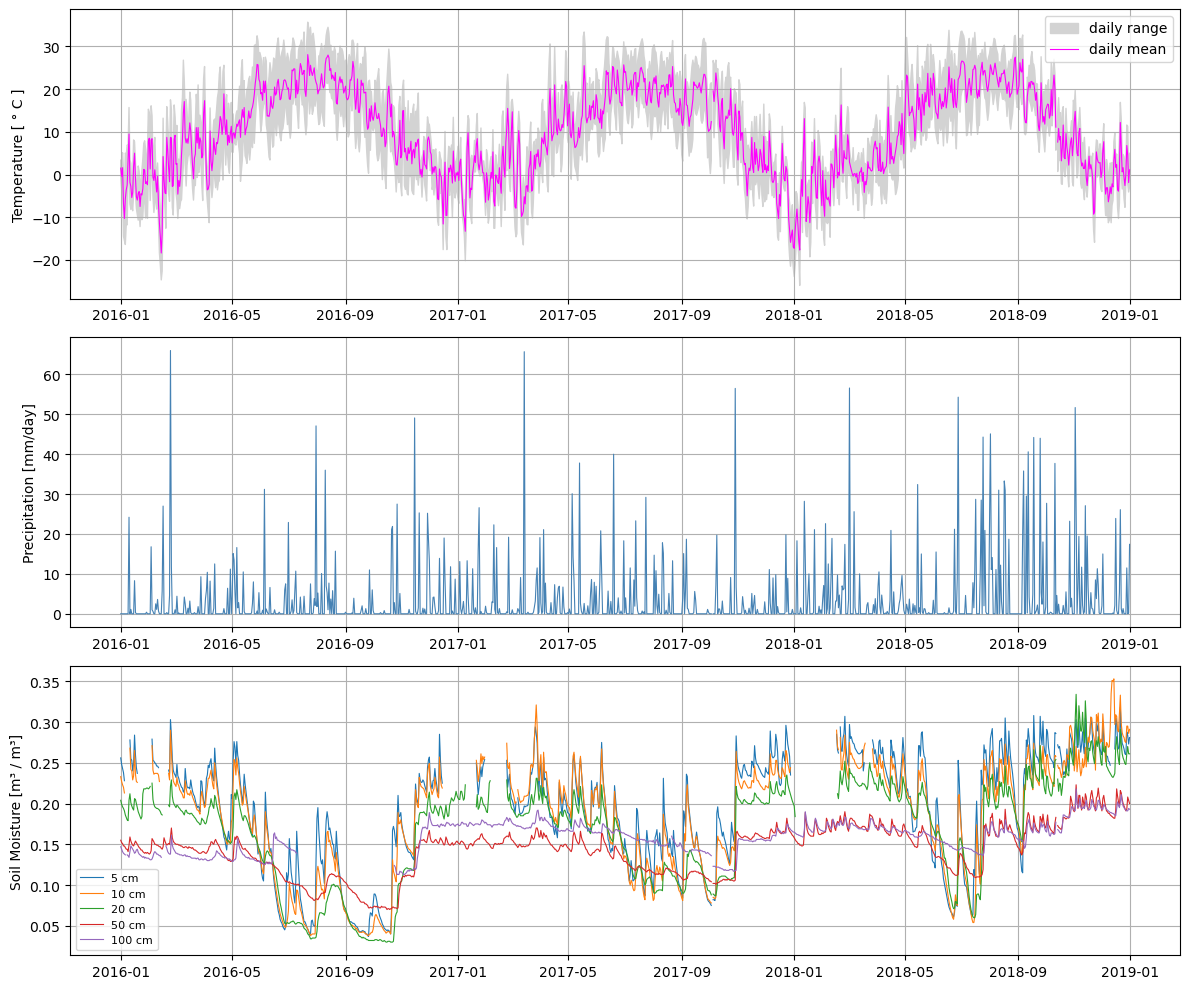

In [2]:
import pooch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep=r'\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')

t_daily_min    = df.T_DAILY_MIN.values
t_daily_max    = df.T_DAILY_MAX.values
t_daily_mean   = df.T_DAILY_MEAN.values
p_daily_calc   = df.P_DAILY_CALC.values
soil_moisture_5   = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10  = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20  = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50  = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

ax1 = axes[0]
ax1.fill_between(date, t_daily_min, t_daily_max, color='lightgrey', label='daily range')
ax1.plot(date, t_daily_mean, color='magenta', linewidth=0.8, label='daily mean')
ax1.set_ylabel("Temperature [ ° C ]")
ax1.legend(loc='upper right')
ax1.grid(True)

ax2 = axes[1]
ax2.plot(date, p_daily_calc, color='steelblue', linewidth=0.8)
ax2.set_ylabel("Precipitation [mm/day]")
ax2.grid(True)

ax3 = axes[2]
ax3.plot(date, soil_moisture_5,   linewidth=0.8, label='5 cm')
ax3.plot(date, soil_moisture_10,  linewidth=0.8, label='10 cm')
ax3.plot(date, soil_moisture_20,  linewidth=0.8, label='20 cm')
ax3.plot(date, soil_moisture_50,  linewidth=0.8, label='50 cm')
ax3.plot(date, soil_moisture_100, linewidth=0.8, label='100 cm')
ax3.set_ylabel("Soil Moisture [m³ / m³]")
ax3.legend(loc='lower left', fontsize=8)
ax3.grid(True)

plt.tight_layout()
plt.show()

### Problem 2: Contour Plots

In [5]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays) 
#### NO XARRAY ALLOWED!
#########################################################

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

ValueError: found the following matches with the input file in xarray's IO backends: ['netcdf4', 'pydap']. But their dependencies may not be installed, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html

### Problem 3: Scatter plots

Unzipping contents of '/home/ld3228/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip' to '/home/ld3228/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip.unzip'


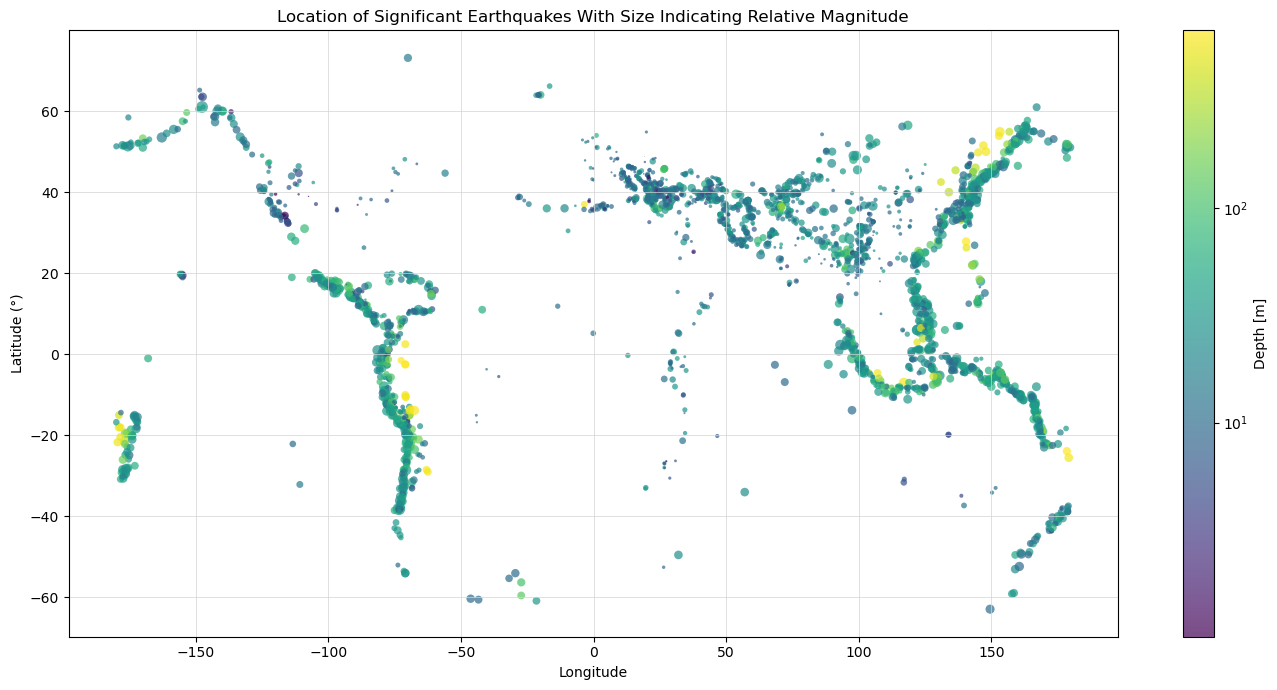

In [6]:
import pooch
import numpy as np
import matplotlib.pyplot as plt

eq_fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes  = np.genfromtxt(eq_fname, delimiter='\t')
depth        = earthquakes[:, 8]
magnitude    = earthquakes[:, 9]
eq_latitude  = earthquakes[:, 20]
eq_longitude = earthquakes[:, 21]

valid = (
    ~np.isnan(eq_longitude) &
    ~np.isnan(eq_latitude)  &
    ~np.isnan(depth)        &
    ~np.isnan(magnitude)    &
    (depth > 0)
)

fig, ax = plt.subplots(figsize=(14, 7))

sc = ax.scatter(
    eq_longitude[valid],
    eq_latitude[valid],
    c=np.log10(depth[valid]),
    s=magnitude[valid]**4 / 100,
    cmap='viridis',
    alpha=0.7,
    linewidths=0,
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Depth [m]')
cbar.set_ticks([1, 2])
cbar.set_ticklabels(['$10^1$', '$10^2$'])

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude (°)')
ax.set_title('Location of Significant Earthquakes With Size Indicating Relative Magnitude')
ax.grid(True, linestyle='-', linewidth=0.5, color='lightgrey')

plt.tight_layout()
plt.show()